# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import random
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure

# Args

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'

# EDA

## Analysis SDF

In [3]:
sdf1, sdf2 = get_item(sdf_nmc_dir, '00000015.hdf5')

In [4]:
sdf1.shape, sdf2.shape

((33, 33, 33), (65, 65, 65))

In [5]:
# dir = '/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/data'
# v, f = igl.read_triangle_mesh(os.path.join(dir, '00000008_9b3d6a97e8de4aa193b81000_trimesh_000.obj'))

In [6]:
# plot(v,f)

In [7]:
verts, faces, normals, values = measure.marching_cubes(sdf1, level=0)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.012687…

In [8]:
mt.plotSlice(sdf2, 0.1)


interactive(children=(IntSlider(value=32, description='s', max=64), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [9]:
mt.plotSlice(sdf2*mt.make_mask_close(sdf2, 65), 0.1)

interactive(children=(IntSlider(value=32, description='s', max=64), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

## Display effect of scale

In [10]:
small_vdb, large_vdb = fu.sdf_to_vdb(sdf1, sdf2, mt.make_mask_close(sdf1, 33), size=33)

`Without scaling the input`

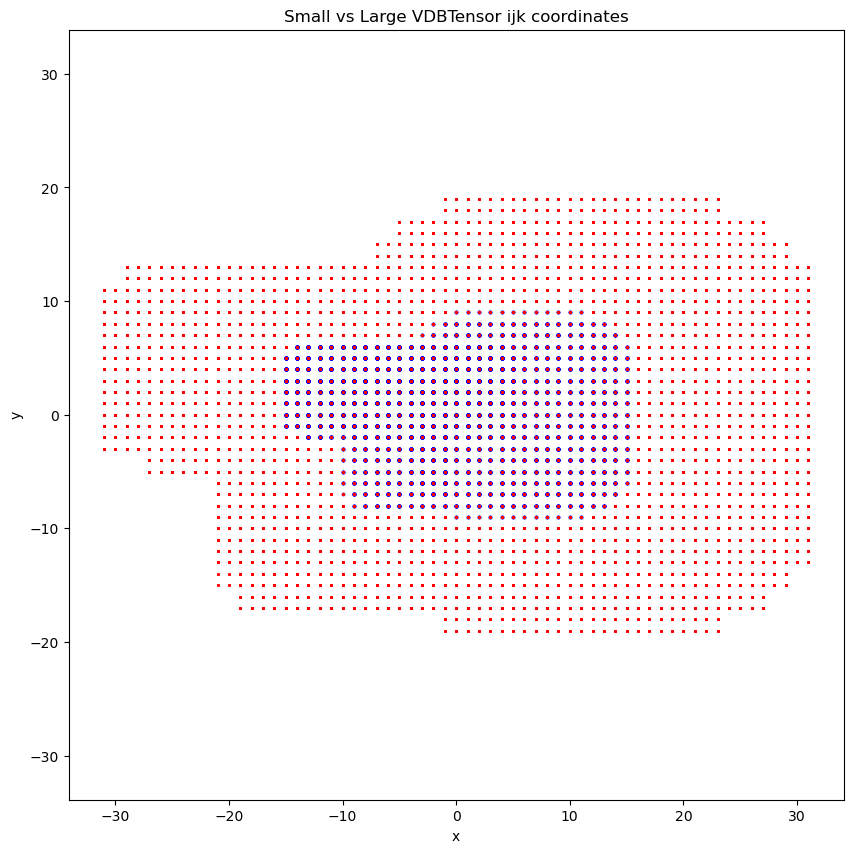

In [11]:
# plot the co-ordinates ijk of the small VDBTensor
plt.figure(figsize=(10, 10))
plt.scatter(small_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), small_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=3, c='b')
plt.scatter(large_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), large_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=1, c='r')
plt.title('Small vs Large VDBTensor ijk coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

`Scaled by 2`

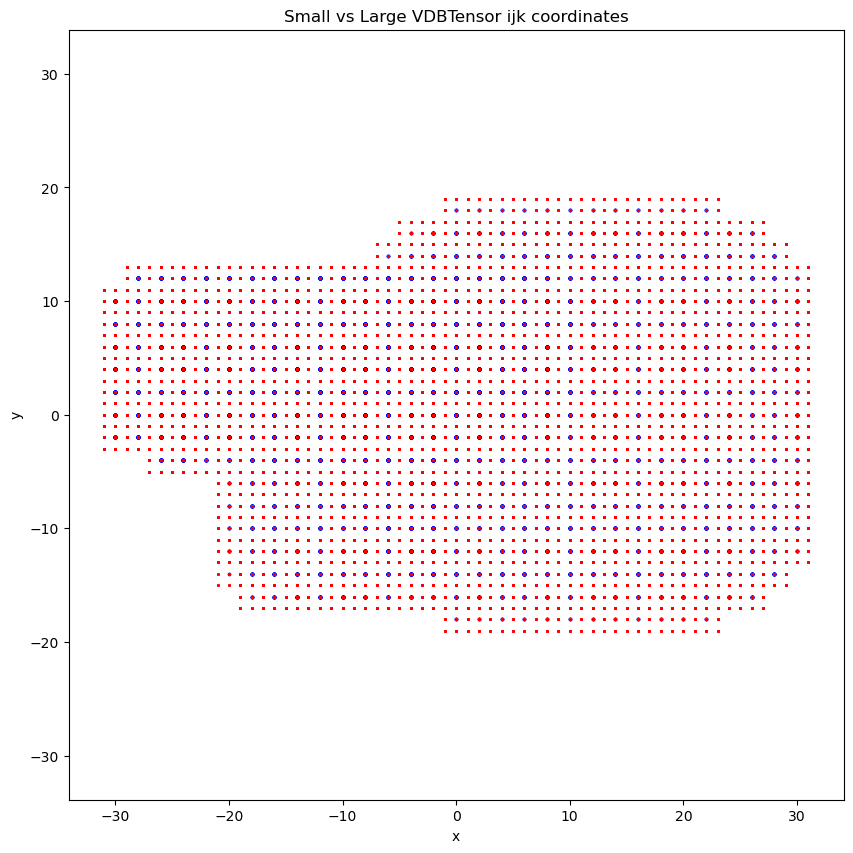

In [12]:
# plot the co-ordinates ijk of the small VDBTensor
plt.figure(figsize=(10, 10))
plt.scatter(2*small_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), 2*small_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=3, c='b')
plt.scatter(large_vdb.grid.ijk.jdata[:, 0].cpu().numpy(), large_vdb.grid.ijk.jdata[:, 1].cpu().numpy(), s=1, c='r')
plt.title('Small vs Large VDBTensor ijk coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

# Load Dataset

In [13]:
with open('../data_utils/abc_watertight_train.txt', 'r') as f:
    train_set_names = [e[:-1] for e in f.readlines()]
train_set_names = train_set_names[:150]

In [21]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(sdf_nmc_dir, train_names)
val_dataset = ABCdataset(sdf_nmc_dir, val_names)
test_dataset = ABCdataset(sdf_nmc_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 30/30 [00:00<00:00, 28946.20it/s]

Number of samples in the dataset: 150
Number of samples in the train set: 90
Number of samples in the test set: 30
Number of samples in the validation set: 30


In [29]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Train Model

In [30]:
print('TODO:  \n - check that the transposed conv is correct \n - add/remove layers \n - add MaxPool to be invariant to sparse grid activations?')

TODO:  
 - check that the transposed conv is correct 
 - add/remove layers 
 - add MaxPool to be invariant to sparse grid activations?


`Position Encoding`

In [31]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

`Without Scaling`

In [32]:
pos_enc_dim = 10
model = fvdbModel.CNN_vanilla(in_channels=pos_enc_dim+1, features=128, out_channels=1)
model = model.to(device)

`Other Param`

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

`Training`

In [34]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            out = model(small_vdb, large_vdb.grid)
            loss = criterion(out.jdata, large_vdb.data.jdata)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)
                out = model(small_vdb, large_vdb.grid)
                loss = criterion(out.jdata, large_vdb.data.jdata)
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        history.append(Loss)

    return history

In [35]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=5, 
                device=device)

Epoch 1/5: 100%|██████████| 90/90 [00:09<00:00,  9.47it/s]


Epoch 1/5, Loss: 1.2756


Validation: 100%|██████████| 30/30 [00:02<00:00, 11.72it/s]


Validation Loss: 0.2688


Epoch 2/5: 100%|██████████| 90/90 [00:08<00:00, 10.02it/s]


...

Validation Loss: 0.0316


Epoch 5/5: 100%|██████████| 90/90 [00:09<00:00,  9.77it/s]


Epoch 5/5, Loss: 0.0365


Validation: 100%|██████████| 30/30 [00:02<00:00, 12.03it/s]

Validation Loss: 0.0212


`Plot history`

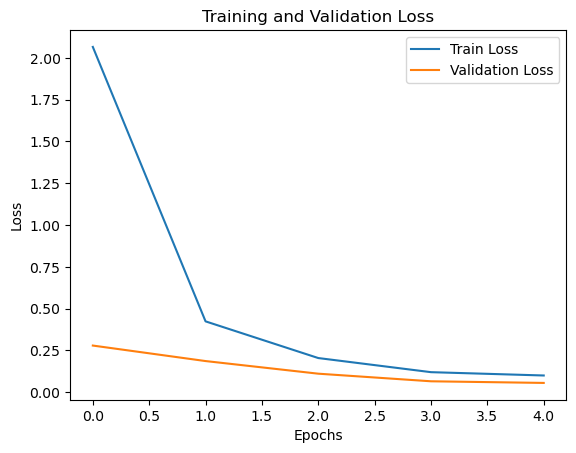

In [ ]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

`display test sample`

In [64]:
# idx = random.randint(0, len(test_dataset)-1)
idx=0
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
input = positional_encoding(input, pos_enc_dim).to(device)
actual = actual.to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')
pred = model(input, large_grid)

In [65]:
v, f = fu.vdb_marching_cubes(small_vdb)
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(5.6847929…

In [66]:
v, f = fu.vdb_marching_cubes(pred)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0009470…

In [67]:
v, f = fu.vdb_marching_cubes(actual)
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(1.2964010…

`Without Transpose`